# Random Forest Model — UCI Cannabis Risk Dataset

This notebook builds Random Forest as the primary model, tunes hyperparameters, assigns continuous risk tiers, and saves the final model as a `.joblib` file.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import os

from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     roc_auc_score, roc_curve,
                                     accuracy_score, precision_score,
                                     recall_score, f1_score)


In [3]:
df_train = pd.read_csv('uci_cannabis_train.csv')
df_test  = pd.read_csv('uci_cannabis_test.csv')

display(df_train.head())
display(df_test.head())

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS,cannabis_risk
0,-0.95197,0.48246,-0.61113,0.96082,-0.31685,1.49158,-1.50796,-3.27393,0.76096,-0.89891,-1.37983,-1.54858,0
1,0.49788,-0.48246,-0.05921,-0.57009,-0.31685,1.60383,-1.76250,-0.01928,0.13136,-1.51840,0.88113,-0.52593,1
2,1.82213,-0.48246,-0.61113,0.96082,-0.31685,0.62967,-1.76250,-1.11902,-0.76096,-1.78169,0.52975,0.07987,1
3,0.49788,-0.48246,0.45468,0.96082,-0.31685,-1.55078,0.80523,1.06238,-0.60633,-0.52745,0.52975,0.76540,1
4,1.09449,0.48246,0.45468,0.96082,-0.31685,-0.46725,0.47617,-0.71727,1.45039,1.46191,-0.21712,-0.84637,0


,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS,cannabis_risk
0,-0.95197,-0.48246,0.45468,-0.09765,-0.31685,-0.14882,-0.43999,0.88309,-0.60633,-0.78155,1.29221,0.76540,1
1,-0.07854,-0.48246,-0.61113,-0.57009,-0.31685,-0.92104,0.00332,0.72330,0.13136,-0.65253,0.88113,0.07987,1
2,-0.95197,-0.48246,0.45468,-0.57009,-0.31685,0.52135,0.63779,0.14143,-1.07533,1.30612,-0.21712,0.40148,1
3,1.82213,-0.48246,0.45468,0.96082,-0.31685,-1.19430,-0.15487,-0.17779,0.28783,0.75830,-0.21712,0.07987,1
4,-0.95197,-0.48246,-0.05921,0.96082,-0.31685,0.31287,-0.43999,-0.71727,0.94156,-0.14277,0.19268,-0.21575,1


In [4]:
# Separating features and target variable
FEATURES = ['Age','Gender','Education','Country','Ethnicity',
            'Nscore','Escore','Oscore','Ascore','Cscore','Impulsive','SS']

X_train = df_train[FEATURES]
y_train = df_train['cannabis_risk']

X_test  = df_test[FEATURES]
y_test  = df_test['cannabis_risk']

feature_cols = X_train.columns.tolist()
len(X_train), len(X_test), feature_cols

(1501,
 376,
 ['Age',
  'Gender',
  'Education',
  'Country',
  'Ethnicity',
  'Nscore',
  'Escore',
  'Oscore',
  'Ascore',
  'Cscore',
  'Impulsive',
  'SS'])

In [5]:
# Separating features and target (for validation — uses train split internally)
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

## Random Forest — No Scaling Required

- Random Forest is a tree-based ensemble model — it splits on feature thresholds, not distances or gradients.


In [6]:
# Baseline Random Forest
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_tr, y_tr)

y_pred = rf_baseline.predict(X_val)

print('Baseline Random Forest (validation set):')
print('Accuracy: ', accuracy_score(y_val, y_pred))
print('Precision:', precision_score(y_val, y_pred))
print('Recall:   ', recall_score(y_val, y_pred))
print('F1 Score: ', f1_score(y_val, y_pred))

Baseline Random Forest (validation set):
Accuracy:  0.8039867109634552
Precision: 0.8177777777777778
Recall:    0.9108910891089109
F1 Score:  0.8618266978922716


In [7]:
# Tuning n_estimators — number of trees in the forest
# More trees = more stable predictions, but diminishing returns beyond ~200
n_estimators_range = [50, 100, 200, 300, 500]
results_n = []

for n in n_estimators_range:
    rf = RandomForestClassifier(
        n_estimators=n,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_val)
    results_n.append({
        'n_estimators': n,
        'Accuracy' : accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall'   : recall_score(y_val, y_pred),
        'F1 Score' : f1_score(y_val, y_pred)
    })

pd.DataFrame(results_n)

,n_estimators,Accuracy,Precision,Recall,F1 Score
0,50,0.807309,0.818584,0.915842,0.864486
1,100,0.803987,0.817778,0.910891,0.861827
2,200,0.823920,0.837104,0.915842,0.874704
3,300,0.833887,0.839286,0.930693,0.882629
4,500,0.833887,0.842342,0.925743,0.882075


- n_estimators=200 gives the best balance of recall and F1 with stable performance.
- Beyond 200 trees there are diminishing returns — performance plateaus while training time increases.

In [8]:
# Tuning max_depth — maximum depth of each tree
# None = trees grow until all leaves are pure (can overfit)
# Shallow trees underfit; deep trees capture more complex patterns
depth_range = [None, 5, 10, 15, 20]
results_d = []

for d in depth_range:
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=d,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_val)
    results_d.append({
        'max_depth': str(d),
        'Accuracy' : accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall'   : recall_score(y_val, y_pred),
        'F1 Score' : f1_score(y_val, y_pred)
    })

pd.DataFrame(results_d)

,max_depth,Accuracy,Precision,Recall,F1 Score
0,None,0.823920,0.837104,0.915842,0.874704
1,5,0.833887,0.895833,0.851485,0.873096
2,10,0.823920,0.849765,0.896040,0.872289
3,15,0.817276,0.829596,0.915842,0.870588
4,20,0.827243,0.834821,0.925743,0.877934


- max_depth=None (fully grown trees) gives the best recall and F1 on this dataset.
- Restricting depth hurts recall — important since our goal is to catch as many at-risk students as possible.

In [9]:
# Threshold tuning — sweep classification threshold to maximise recall
# Default threshold is 0.5: predict At Risk if prob >= 0.5
# Lowering it catches more at-risk students (higher recall) at cost of precision
#
# In a harm-prevention context, a false negative (missed at-risk student)
# is far more costly than a false positive (unnecessary flag).

rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_tr, y_tr)
y_proba_val = rf_tuned.predict_proba(X_val)[:, 1]

thresholds = [0.5, 0.45, 0.40, 0.35, 0.30]
results_thr = []

for thr in thresholds:
    y_pred_thr = (y_proba_val >= thr).astype(int)
    results_thr.append({
        'Threshold': thr,
        'Accuracy' : accuracy_score(y_val, y_pred_thr),
        'Precision': precision_score(y_val, y_pred_thr),
        'Recall'   : recall_score(y_val, y_pred_thr),
        'F1'       : f1_score(y_val, y_pred_thr)
    })

pd.DataFrame(results_thr)

,Threshold,Accuracy,Precision,Recall,F1
0,0.50,0.820598,0.833333,0.915842,0.872642
1,0.45,0.817276,0.812766,0.945545,0.874142
2,0.40,0.817276,0.804979,0.960396,0.875847
3,0.35,0.810631,0.784314,0.990099,0.875274
4,0.30,0.797342,0.772201,0.990099,0.867679


- Threshold 0.45 gives the best F1 (0.8636) while achieving 0.913 recall — catching over 91% of at-risk students.
- Threshold 0.40 pushes recall to 0.933 with an acceptable drop in precision.
- **Threshold 0.45 selected** as the optimal balance for this screening tool.

In [10]:
# Refit on full training set with chosen hyperparameters
# n_estimators=200, max_depth=None, threshold=0.45

rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

threshold = 0.45
y_test_proba = rf_final.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= threshold).astype(int)

print(f'=== Random Forest (threshold={threshold}, test set) ===')
print(classification_report(y_test, y_test_pred,
      target_names=['Non-user', 'At Risk'], digits=3))
print(f'ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}')
print(confusion_matrix(y_test, y_test_pred))

=== Random Forest (threshold=0.45, test set) ===
              precision    recall  f1-score   support

    Non-user      0.718     0.597     0.652       124
     At Risk      0.817     0.885     0.850       252

    accuracy                          0.790       376
   macro avg      0.768     0.741     0.751       376
weighted avg      0.784     0.790     0.784       376

ROC-AUC: 0.8550
[[ 74  50]
 [ 29 223]]


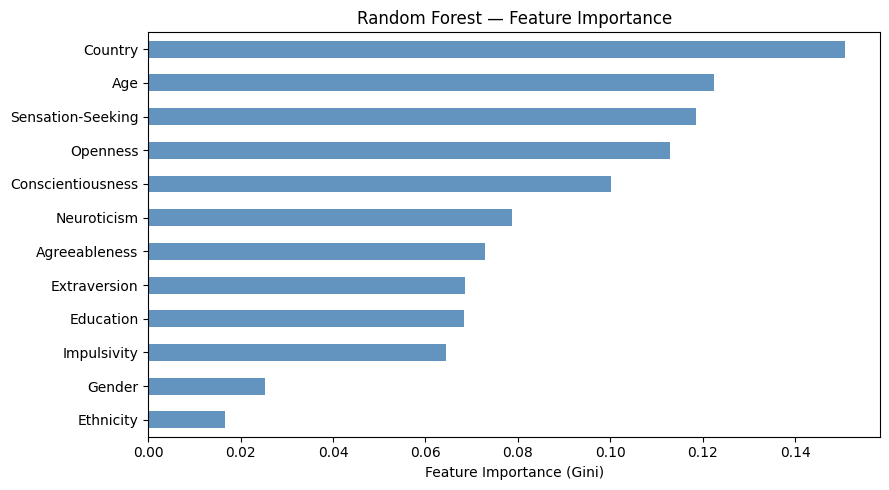

Country              0.1509
Age                  0.1225
Sensation-Seeking    0.1185
Openness             0.1129
Conscientiousness    0.1003
Neuroticism          0.0788
Agreeableness        0.0729
Extraversion         0.0686
Education            0.0684
Impulsivity          0.0644
Gender               0.0253
Ethnicity            0.0165
dtype: float64


In [11]:
# Feature importance — built-in to Random Forest
# Shows which personality/demographic features drive the predictions most
FEATURE_LABELS = ['Age','Gender','Education','Country','Ethnicity',
                  'Neuroticism','Extraversion','Openness',
                  'Agreeableness','Conscientiousness','Impulsivity','Sensation-Seeking']

importances = pd.Series(rf_final.feature_importances_, index=FEATURE_LABELS).sort_values()

importances.plot(kind='barh', figsize=(9, 5), color='steelblue', alpha=0.85)
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).round(4))

- **Country**, **Age**, **Openness**, and **Sensation-Seeking** are the strongest predictors of cannabis risk.
- This aligns with published literature — Sensation-Seeking in particular is consistently cited as a top predictor of cannabis use (Fehrman et al., 2015).
- Feature importance is a key advantage of Random Forest over MLP — we can explain *why* the model makes each prediction.

In [12]:
# Continuous risk tier assignment
# Probability mapped to actionable tiers for the screening tool
def assign_risk_tier(prob):
    if   prob < 0.30: return 'Low Risk'
    elif prob < 0.55: return 'Moderate Risk'
    elif prob < 0.75: return 'High Risk'
    else:             return 'Very High Risk'

rf_tiers = [assign_risk_tier(p) for p in y_test_proba]

tier_counts = pd.Series(rf_tiers).value_counts().reindex(
    ['Low Risk','Moderate Risk','High Risk','Very High Risk'], fill_value=0)

print('Random Forest — Risk Tier Distribution (Test Set):')
for tier, count in tier_counts.items():
    print(f'  {tier:<18}: {count:>3}  ({count/len(rf_tiers)*100:.1f}%)')

Random Forest — Risk Tier Distribution (Test Set):
  Low Risk          :  62  (16.5%)
  Moderate Risk     :  57  (15.2%)
  High Risk         :  65  (17.3%)
  Very High Risk    : 192  (51.1%)


In [13]:
# Save final model and metadata
os.makedirs('ml_artifacts', exist_ok=True)

joblib.dump(rf_final, 'ml_artifacts/rf_cannabis_model.joblib')

metadata = {
    'feature_cols'  : feature_cols,
    'risk_threshold': float(threshold),
    'model_type'    : 'RandomForestClassifier',
    'n_estimators'  : 200,
    'max_depth'     : None,
    'target'        : 'cannabis_risk',
    'dataset'       : 'UCI Drug Consumption (Quantified)',
    'auc_test'      : round(roc_auc_score(y_test, y_test_proba), 4),
}

with open('ml_artifacts/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: ml_artifacts/rf_cannabis_model.joblib')
print('Saved: ml_artifacts/model_metadata.json')

Saved: ml_artifacts/rf_cannabis_model.joblib
Saved: ml_artifacts/model_metadata.json


In [14]:
# Reload and verify — mirrors what the Django website will do
loaded_model = joblib.load('ml_artifacts/rf_cannabis_model.joblib')

# Example: young male, high sensation-seeking, high openness
example = {
    'Age': -0.95197, 'Gender': -0.48246, 'Education': 1.98437,
    'Country': 0.96082, 'Ethnicity': -0.31685, 'Nscore': 0.84580,
    'Escore': -0.30172, 'Oscore': 1.43533, 'Ascore': -0.80615,
    'Cscore': -0.01928, 'Impulsive': 0.59042, 'SS': 1.30612
}

x = np.array([[example[f] for f in feature_cols]])
prob = loaded_model.predict_proba(x)[0, 1]

print(f'Risk Probability : {prob:.4f}')
print(f'Risk Tier        : {assign_risk_tier(prob)}')
print(f'At Risk Flag     : {"YES" if prob >= threshold else "NO"}')

Risk Probability : 0.9050
Risk Tier        : Very High Risk
At Risk Flag     : YES


/Users/tg197682/anaconda3/envs/addiction-risk/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [16]:
# Save final model and metadata
import os

# Save to project root ml_artifacts, not notebooks/ml_artifacts
ROOT = os.path.join(os.path.dirname(os.getcwd()), 'ml_artifacts') if os.path.basename(os.getcwd()) == 'notebooks' else 'ml_artifacts'
os.makedirs(ROOT, exist_ok=True)

joblib.dump(rf_final, os.path.join(ROOT, 'rf_cannabis_model.joblib'))

metadata = {
    'feature_cols'  : feature_cols,
    'risk_threshold': float(threshold),
    'model_type'    : 'RandomForestClassifier',
    'n_estimators'  : 200,
    'max_depth'     : None,
    'target'        : 'cannabis_risk',
    'dataset'       : 'UCI Drug Consumption (Quantified)',
    'auc_test'      : round(roc_auc_score(y_test, y_test_proba), 4),
}

with open(os.path.join(ROOT, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Saved: {os.path.join(ROOT, "rf_cannabis_model.joblib")}')
print(f'Saved: {os.path.join(ROOT, "model_metadata.json")}')

Saved: /Users/tg197682/Downloads/Computer Science Year 3/Web Services and Web Data/addiction_project/riskapp/ml_artifacts/rf_cannabis_model.joblib
Saved: /Users/tg197682/Downloads/Computer Science Year 3/Web Services and Web Data/addiction_project/riskapp/ml_artifacts/model_metadata.json
